In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
DATA_PATH = Path("../data/processed/final_security.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH.resolve()}"
    )

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (9230, 13)


,comment_id,comment,repo,language,pr_id,c_id,matched_strong,matched_weak,security_categories,candidate_score,indicator_strength,security_label,review_notes
0,208849771,Should not `ansible.utils.encrypt.random_passw...,ansible,Python,21225735,1095841089,NaN,password; encryption,authentication; cryptography,2,weak,0,"Keyword appears while describing, implementing..."
1,258431281,These routes are quite a lot to copy in here. ...,AspNetCore,NaN,56148722,1303642745,NaN,authorization; authorize,authorization,2,weak,0,"Keyword appears while describing, implementing..."
2,269690752,slow-tests does also contain ssl-certificate r...,chainweb-node,Haskell,58703769,1341744273,NaN,ssl; certificate,cryptography,2,weak,0,"Keyword appears while describing, implementing..."
3,195074858,minikube start --bootstrapper localkube --extr...,service-manager,NaN,39143713,1005582331,NaN,authorization; authorize,authorization,2,weak,0,"Keyword appears while describing, implementing..."
4,224629987,There might be some confusion. I ran this cod...,hail,Scala,47236096,1161354134,NaN,secret; session,authentication; secrets,2,weak,1,Comment explicitly describes a security weakne...


In [3]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate full rows:", df.duplicated().sum())

if "comment_id" in df.columns:
    print(
        "Duplicate comment IDs:",
        df["comment_id"].duplicated().sum()
    )

Columns:
['comment_id', 'comment', 'repo', 'language', 'pr_id', 'c_id', 'matched_strong', 'matched_weak', 'security_categories', 'candidate_score', 'indicator_strength', 'security_label', 'review_notes']

Data types:


comment_id             int64
comment                  str
repo                     str
language                 str
pr_id                  int64
c_id                   int64
matched_strong           str
matched_weak             str
security_categories      str
candidate_score        int64
indicator_strength       str
security_label         int64
review_notes             str
dtype: object


Missing values:


comment_id                0
comment                   0
repo                      0
language               2402
pr_id                     0
c_id                      0
matched_strong         6531
matched_weak           2047
security_categories       0
candidate_score           0
indicator_strength        0
security_label            0
review_notes              0
dtype: int64


Duplicate full rows: 0
Duplicate comment IDs: 0


In [4]:
TEXT_COLUMN = "comment"
LABEL_COLUMN = "security_label"

if TEXT_COLUMN not in df.columns:
    raise ValueError(
        f"Missing required column: {TEXT_COLUMN}"
    )

if LABEL_COLUMN not in df.columns:
    raise ValueError(
        f"Missing required column: {LABEL_COLUMN}"
    )

df[TEXT_COLUMN] = (
    df[TEXT_COLUMN]
    .fillna("")
    .astype(str)
    .str.strip()
)

print("Blank comments:",
      (df[TEXT_COLUMN] == "").sum())

print("\nOriginal label distribution:")
display(df[LABEL_COLUMN].value_counts().sort_index())

Blank comments: 0

Original label distribution:


security_label
0    6119
1    3028
2      83
Name: count, dtype: int64

In [5]:
df_binary = df[
    df[LABEL_COLUMN].isin([0, 1])
].copy()

df_binary = df_binary[
    df_binary[TEXT_COLUMN] != ""
].copy()

df_binary[LABEL_COLUMN] = (
    df_binary[LABEL_COLUMN]
    .astype(int)
)

print("Binary dataset shape:", df_binary.shape)

print("\nBinary label distribution:")
display(
    df_binary[LABEL_COLUMN]
    .value_counts()
    .sort_index()
)

Binary dataset shape: (9147, 13)

Binary label distribution:


security_label
0    6119
1    3028
Name: count, dtype: int64

In [6]:
X = df_binary[TEXT_COLUMN]
y = df_binary[LABEL_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print("\nTraining distribution:")
display(y_train.value_counts().sort_index())

print("\nTesting distribution:")
display(y_test.value_counts().sort_index())

Training rows: 7317
Testing rows: 1830

Training distribution:


security_label
0    4895
1    2422
Name: count, dtype: int64


Testing distribution:


security_label
0    1224
1     606
Name: count, dtype: int64

In [7]:
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (7317, 14862)
Testing TF-IDF shape: (1830, 14862)


In [8]:
logistic_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

logistic_model.fit(
    X_train_tfidf,
    y_train
)

logistic_predictions = logistic_model.predict(
    X_test_tfidf
)

In [9]:
svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42
)

svm_model.fit(
    X_train_tfidf,
    y_train
)

svm_predictions = svm_model.predict(
    X_test_tfidf
)

In [10]:
def evaluate_model(model_name, y_true, predictions):
    print(model_name)
    print("-" * 50)

    print(
        "Accuracy:",
        round(accuracy_score(y_true, predictions), 4)
    )

    print(
        "Balanced accuracy:",
        round(
            balanced_accuracy_score(y_true, predictions),
            4
        )
    )

    print(
        "Precision:",
        round(
            precision_score(
                y_true,
                predictions,
                zero_division=0
            ),
            4
        )
    )

    print(
        "Recall:",
        round(
            recall_score(
                y_true,
                predictions,
                zero_division=0
            ),
            4
        )
    )

    print(
        "F1-score:",
        round(
            f1_score(
                y_true,
                predictions,
                zero_division=0
            ),
            4
        )
    )

    print("\nClassification report:")
    print(
        classification_report(
            y_true,
            predictions,
            target_names=[
                "Not security-related",
                "Security-related"
            ],
            zero_division=0
        )
    )


evaluate_model(
    "Logistic Regression",
    y_test,
    logistic_predictions
)

evaluate_model(
    "Linear SVM",
    y_test,
    svm_predictions
)

Logistic Regression
--------------------------------------------------


Accuracy: 0.9705
Balanced accuracy: 0.9563


Precision: 0.9964
Recall: 0.9142
F1-score: 0.9535

Classification report:
                      precision    recall  f1-score   support

Not security-related       0.96      1.00      0.98      1224
    Security-related       1.00      0.91      0.95       606

            accuracy                           0.97      1830
           macro avg       0.98      0.96      0.97      1830
        weighted avg       0.97      0.97      0.97      1830

Linear SVM
--------------------------------------------------
Accuracy: 0.976
Balanced accuracy: 0.9649
Precision: 0.9947
Recall: 0.9323
F1-score: 0.9625

Classification report:
                      precision    recall  f1-score   support

Not security-related       0.97      1.00      0.98      1224
    Security-related       0.99      0.93      0.96       606

            accuracy                           0.98      1830
           macro avg       0.98      0.96      0.97      1830
        weighted avg       0.98      0.98      0.98      1830

In [11]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Linear SVM"
    ],
    "Accuracy": [
        accuracy_score(y_test, logistic_predictions),
        accuracy_score(y_test, svm_predictions)
    ],
    "Balanced Accuracy": [
        balanced_accuracy_score(
            y_test,
            logistic_predictions
        ),
        balanced_accuracy_score(
            y_test,
            svm_predictions
        )
    ],
    "Precision": [
        precision_score(
            y_test,
            logistic_predictions,
            zero_division=0
        ),
        precision_score(
            y_test,
            svm_predictions,
            zero_division=0
        )
    ],
    "Recall": [
        recall_score(
            y_test,
            logistic_predictions,
            zero_division=0
        ),
        recall_score(
            y_test,
            svm_predictions,
            zero_division=0
        )
    ],
    "F1-score": [
        f1_score(
            y_test,
            logistic_predictions,
            zero_division=0
        ),
        f1_score(
            y_test,
            svm_predictions,
            zero_division=0
        )
    ]
})

results = results.round(4)

display(results)

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.9705,0.9563,0.9964,0.9142,0.9535
1,Linear SVM,0.9760,0.9649,0.9947,0.9323,0.9625


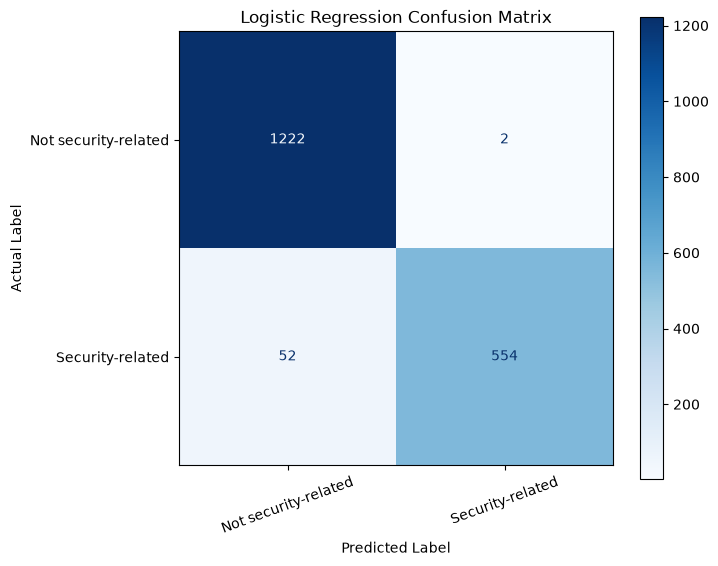

In [12]:
logistic_cm = confusion_matrix(
    y_test,
    logistic_predictions,
    labels=[0, 1]
)

fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=logistic_cm,
    display_labels=[
        "Not security-related",
        "Security-related"
    ]
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks(rotation=20)
plt.yticks(rotation=0)
plt.show()

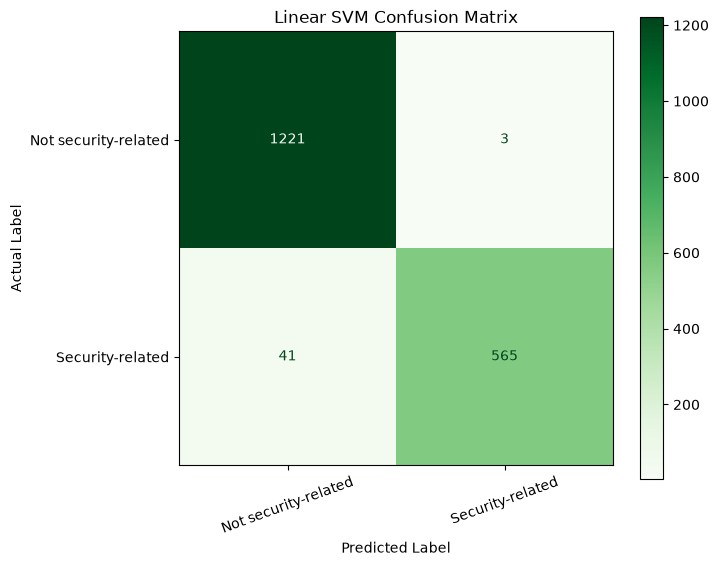

In [13]:
svm_cm = confusion_matrix(
    y_test,
    svm_predictions,
    labels=[0, 1]
)

fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=svm_cm,
    display_labels=[
        "Not security-related",
        "Security-related"
    ]
)

disp.plot(
    ax=ax,
    cmap="Greens",
    values_format="d"
)

plt.title("Linear SVM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.xticks(rotation=20)
plt.yticks(rotation=0)
plt.show()

In [14]:
error_analysis = pd.DataFrame({
    "comment_id": df_binary.loc[
        X_test.index,
        "comment_id"
    ].values,
    "comment": X_test.values,
    "actual_label": y_test.values,
    "svm_prediction": svm_predictions
})

error_analysis["result"] = np.where(
    (error_analysis["actual_label"] == 1) &
    (error_analysis["svm_prediction"] == 1),
    "True Positive",
    np.where(
        (error_analysis["actual_label"] == 0) &
        (error_analysis["svm_prediction"] == 0),
        "True Negative",
        np.where(
            (error_analysis["actual_label"] == 0) &
            (error_analysis["svm_prediction"] == 1),
            "False Positive",
            "False Negative"
        )
    )
)

print("Prediction result counts:")
display(
    error_analysis["result"]
    .value_counts()
)

Prediction result counts:


result
True Negative     1221
True Positive      565
False Negative      41
False Positive       3
Name: count, dtype: int64

In [15]:
false_positives = error_analysis[
    error_analysis["result"] == "False Positive"
].copy()

print("False positives:", len(false_positives))

display(
    false_positives[
        [
            "comment_id",
            "comment",
            "actual_label",
            "svm_prediction"
        ]
    ].head(50)
)

False positives: 3


,comment_id,comment,actual_label,svm_prediction
252,208493130,The email is displayed in the user nav bar. Th...,0,1
1132,246165714,"my concern is the current name is too general,...",0,1
1365,287533732,"Shall we also test ServiceRoleBinding, which i...",0,1


In [16]:
false_negatives = error_analysis[
    error_analysis["result"] == "False Negative"
].copy()

print("False negatives:", len(false_negatives))

display(
    false_negatives[
        [
            "comment_id",
            "comment",
            "actual_label",
            "svm_prediction"
        ]
    ].head(50)
)

False negatives: 41


,comment_id,comment,actual_label,svm_prediction
20,257410055,Notebook has no control over the authorization...,1,0
153,248428300,"Out of curiosity, this means that we're Authen...",1,0
158,215326921,"Pedantic, but it is possible to create a worku...",1,0
191,256440035,This is the client giving the server a valid a...,1,0
249,250529654,Sending bearer tokens un-encrypted over the wi...,1,0
325,265959453,"Hm, yes we could. The token will end up in the...",1,0
334,242920176,Single-user is not a case at all. There is no ...,1,0
335,225763433,Thanks @sdake and @monotek for the discussion ...,1,0
336,230755993,@beyang @keegancsmith @sqs currently our sessi...,1,0
462,285115485,"We discussed this in the call, decision was: l...",1,0


In [17]:
svm_scores = svm_model.decision_function(
    X_test_tfidf
)

error_analysis["svm_score"] = svm_scores

error_analysis["distance_from_boundary"] = (
    np.abs(error_analysis["svm_score"])
)

least_confident = error_analysis.sort_values(
    by="distance_from_boundary",
    ascending=True
)

display(
    least_confident[
        [
            "comment_id",
            "comment",
            "actual_label",
            "svm_prediction",
            "svm_score",
            "distance_from_boundary",
            "result"
        ]
    ].head(50)
)

,comment_id,comment,actual_label,svm_prediction,svm_score,distance_from_boundary,result
713,219679274,"Well, I know why decryption is initialized ins...",0,0,-0.007383,0.007383,True Negative
1650,214630298,for the record: components should use tacokit ...,1,1,0.020060,0.020060,True Positive
763,251131826,@iilyak thanks for pointing out those requirem...,0,0,-0.047482,0.047482,True Negative
1376,237169656,Paperclip actually doesn't sanitize the file n...,1,1,0.049178,0.049178,True Positive
693,254610016,This is the Travis way to provide secure keys....,1,1,0.050228,0.050228,True Positive
1365,287533732,"Shall we also test ServiceRoleBinding, which i...",0,1,0.051914,0.051914,False Positive
325,265959453,"Hm, yes we could. The token will end up in the...",1,0,-0.052725,0.052725,False Negative
1404,263983468,Thanks for catching this security issue. I res...,1,1,0.057103,0.057103,True Positive
753,243339713,"Given a cursor set, you should be (in principl...",1,1,0.068548,0.068548,True Positive
1253,230231410,It would be way easier I think to just use the...,0,0,-0.069377,0.069377,True Negative


In [18]:
model_comparison = pd.DataFrame({
    "comment_id": df_binary.loc[
        X_test.index,
        "comment_id"
    ].values,
    "comment": X_test.values,
    "actual_label": y_test.values,
    "logistic_prediction": logistic_predictions,
    "svm_prediction": svm_predictions
})

model_disagreements = model_comparison[
    model_comparison["logistic_prediction"] !=
    model_comparison["svm_prediction"]
].copy()

print(
    "Number of model disagreements:",
    len(model_disagreements)
)

display(model_disagreements.head(50))

Number of model disagreements: 14


,comment_id,comment,actual_label,logistic_prediction,svm_prediction
67,247053880,"I have not tested, but this looks like a secur...",1,0,1
181,222617322,insecur**e**\```go\// Insecure disables client...,1,0,1
211,280275567,```suggestion\Provided that your Google Play D...,1,0,1
252,208493130,The email is displayed in the user nav bar. Th...,0,0,1
656,214662488,Do we need a default value for a secret in the...,1,0,1
672,282392406,@rvl I am not sure are you ok with this change...,1,0,1
683,267436233,Is it OK to make this information public? If ...,1,0,1
812,287555815,"Good catch, that's one stupid security hole I ...",1,0,1
1365,287533732,"Shall we also test ServiceRoleBinding, which i...",0,0,1
1376,237169656,Paperclip actually doesn't sanitize the file n...,1,0,1


In [19]:
df_binary["language_clean"] = (
    df_binary["language"]
    .fillna("Unknown")
    .replace("", "Unknown")
)

language_summary = (
    df_binary
    .groupby(
        ["language_clean", LABEL_COLUMN]
    )
    .size()
    .unstack(fill_value=0)
)

display(language_summary)

security_label,0,1
language_clean,,
API Blueprint,2,0
Agda,1,0
Batchfile,20,0
C,105,103
C#,230,59
...,...,...
Unknown,1663,722
VHDL,0,2
VimL,0,1


In [20]:
category_counts = (
    df_binary["security_categories"]
    .fillna("Unknown")
    .value_counts()
)

display(category_counts.head(30))

security_categories
authentication; secrets                      1287
vulnerability                                1280
authorization                                1126
cryptography                                  776
injection                                     452
authentication; cryptography                  391
cryptography; secrets                         323
authorization; secrets                        292
authentication                                281
general_security; vulnerability               272
authentication; authorization                 259
cryptography; general_security                254
authorization; general_security               186
secrets                                       175
memory_safety                                 151
general_security; secrets                     151
authentication; authorization; secrets        119
authentication; general_security              117
input_validation; secrets                     111
authentication; input_validati